In [1]:
import pandas as pd  
import numpy as np
import xgboost
import matplotlib.pyplot as plot
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split


In [2]:
Data = pd.read_csv("adults_drop.csv")
X = Data
#print(X)
y = Data['hoursperweek']
print(y)
X.drop('hoursperweek', axis=1, inplace=True)

0        40
1        13
2        40
3        40
4        40
         ..
45217    40
45218    36
45219    50
45220    40
45221    60
Name: hoursperweek, Length: 45222, dtype: int64


In [3]:
X['workclass'], value = pd.factorize(X['workclass'])
print("1",value)
X['education'], value = pd.factorize(X['education'])
print("2",value)
X['maritalstatus'], value = pd.factorize(X['maritalstatus'])
print("3",value)
X['occupation'], value = pd.factorize(X['occupation'])
print("4",value)
X['relationship'], value = pd.factorize(X['relationship'])
print("5",value)
X['race'], value = pd.factorize(X['race'])
print("6",value)
X['sex'], value = pd.factorize(X['sex'])
print("7",value)
X['nativecountry'], value = pd.factorize(X['nativecountry'])
print("9",value)
X['income'], value = pd.factorize(X['income'])
print("9",value)
# y, value = pd.factorize(y)
# print("10",value)
# print(y)

1 Index(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov',
       'Self-emp-inc', 'Without-pay'],
      dtype='object')
2 Index(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', '7th-8th', 'Doctorate', 'Assoc-voc', 'Prof-school',
       '5th-6th', '10th', 'Preschool', '12th', '1st-4th'],
      dtype='object')
3 Index(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed'],
      dtype='object')
4 Index(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Transport-moving',
       'Farming-fishing', 'Machine-op-inspct', 'Tech-support', 'Craft-repair',
       'Protective-serv', 'Armed-Forces', 'Priv-house-serv'],
      dtype='object')
5 Index(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'],
      dtype='object')
6 Index(['White', 'Black', 'Asian-Pac-Islander', 'A

In [4]:
model = xgboost.XGBRegressor()
model.fit(X, y)
print(model.feature_importances_)
#xgboost.plot_importance(Data, importance_type='cover')

[0.13544847 0.06069852 0.02516084 0.03689091 0.03449864 0.06087025
 0.08566231 0.02793597 0.26799858 0.03077584 0.02398556 0.0251269
 0.18494718]


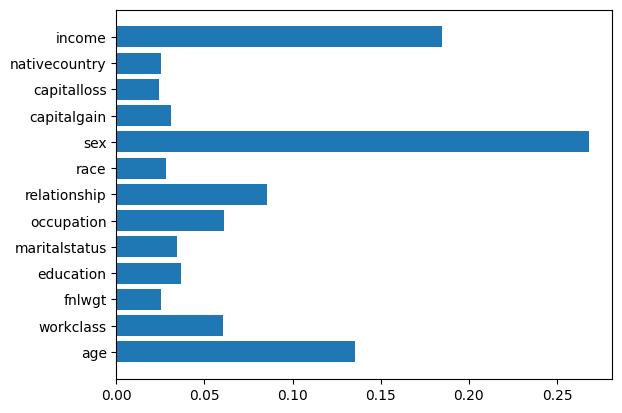

In [5]:
plot.barh(X.columns, model.feature_importances_)
plot.show()

# {0, age}, {1, workclass}, {2, fnlwgt}, {3, education}, {4, education-num}, {5, marital-status}, {6, occupation}, {7, relationship}.
# {8, race}, {9, sex}, {10, capital-gain}, {11, capital-loss}, {12, hours-per-week}, {13, native-country}, {14, income}

In [6]:
Data = pd.read_csv("adults.csv")
X2 = Data
y2 = Data['hoursperweek']
print(y2)

0        2
1        0
2        2
3        2
4        2
        ..
48837    2
48838    2
48839    3
48840    2
48841    3
Name: hoursperweek, Length: 48842, dtype: int64


In [7]:
#X2.drop('income', axis=1, inplace=True)

# X2.drop('age', axis=1, inplace=True)    #0
# X2.drop('workclass', axis=1, inplace=True)  #1
# X2.drop('fnlwgt', axis=1, inplace=True)    #2
# X2.drop('education', axis=1, inplace=True) #3
# X2.drop('education-num', axis=1, inplace=True) #4
# X2.drop('marital-status', axis=1, inplace=True) #5
# X2.drop('occupation', axis=1, inplace=True) #6
# X2.drop('relationship', axis=1, inplace=True) #7
# X2.drop('race', axis=1, inplace=True) #8
# X2.drop('sex', axis=1, inplace=True) #9
# X2.drop('capitalgain', axis=1, inplace=True) #10
# X2.drop('capitalloss', axis=1, inplace=True) #11
X2.drop('hoursperweek', axis=1, inplace=True) #12
# X2.drop('native-country', axis=1, inplace=True) #13
# X2.drop('income', axis=1, inplace=True) #14

print(X2)

       age         workclass  fnlwgt  education  education-num  \
0        2         State-gov   77516  Bachelors             13   
1        3  Self-emp-not-inc   83311  Bachelors             13   
2        2           Private  215646    HS-grad              9   
3        3           Private  234721       11th              7   
4        1           Private  338409  Bachelors             13   
...    ...               ...     ...        ...            ...   
48837    2           Private  215419  Bachelors             13   
48838    4               NaN  321403    HS-grad              9   
48839    2           Private  374983  Bachelors             13   
48840    2           Private   83891  Bachelors             13   
48841    1      Self-emp-inc  182148  Bachelors             13   

           marital-status         occupation    relationship  \
0           Never-married       Adm-clerical   Not-in-family   
1      Married-civ-spouse    Exec-managerial         Husband   
2              

In [8]:
X2['marital-status'], value = pd.factorize(X2['marital-status'])
print("1",value)
X2['relationship'], value = pd.factorize(X2['relationship'])
print("2",value)
X2['workclass'], value = pd.factorize(X2['workclass'])
print("3",value)
X2['education'], value = pd.factorize(X2['education'])
print("4",value)
X2['occupation'], value = pd.factorize(X2['occupation'])
print("5",value)
X2['race'], value = pd.factorize(X2['race'])
print("6",value)
X2['sex'], value = pd.factorize(X2['sex'])
print("7",value)
X2['native-country'], value = pd.factorize(X2['native-country'])
print("8",value)
X2['income'], value = pd.factorize(X2['income'])
print("9",value)
# y2, value = pd.factorize(y2)
# print("9",value)
# print(y2)

1 Index(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed'],
      dtype='object')
2 Index(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'],
      dtype='object')
3 Index(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov',
       'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype='object')
4 Index(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'],
      dtype='object')
5 Index(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Protective-serv', 'Armed-Forces', 'Priv-house-serv'],
      dtype='object')
6 Index(['White', 'Black', 'Asian-P

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X2['fnlwgt'] = scaler.fit_transform(X2[['fnlwgt']])


In [10]:
model = xgboost.XGBRegressor(max_detph = 4)
model.fit(X2, y2)
thresholds = np.sort(model.feature_importances_)
print(thresholds)

c:\Users\GameR\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:160: UserWarning: [17:42:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0750514818a16474a-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "max_detph" } are not used.

  warnings.warn(smsg, UserWarning)


[0.02017116 0.02017857 0.02073365 0.02216145 0.02450808 0.03105856
 0.03304925 0.04390823 0.05135989 0.06320158 0.12781629 0.14286116
 0.18746355 0.21152858]


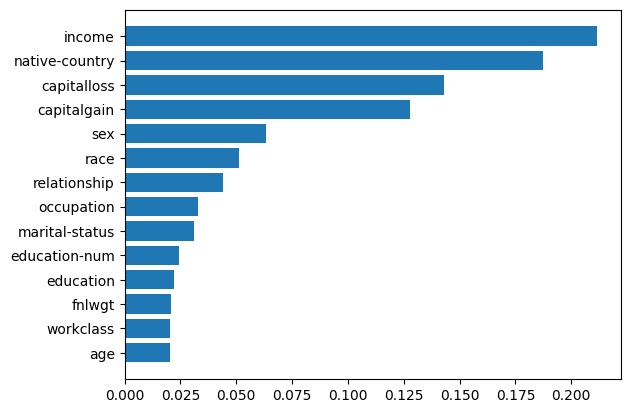

In [11]:
plot.barh(X2.columns, thresholds)
plot.show()

In [12]:

#print(thresholds)
#print(len(thresholds))
train_X, test_X, train_y, test_y = train_test_split(X2, y2, test_size = 0.3, random_state = 25) 
train_X, valid_X, train_y, valid_y = train_test_split(train_X, train_y, test_size = 0.3, random_state = 25)
print('測試集: ',model.score(test_X, test_y))
print('訓練集: ',model.score(train_X, train_y))

測試集:  0.39211059979636265
訓練集:  0.40130036539026115


In [13]:
thresholds = np.sort(model.feature_importances_)
# pred = model.predict(valid_X)
# plot.barh(train_X.columns, model.feature_importances_)
# plot.show()
for thresh in thresholds:
    # select features using threshold
    selection = SelectFromModel(model, threshold = thresh)
    select_X_train = selection.transform(train_X) # 選択した特徴量の列のみ取得
    # train model
    selection_model = xgboost.XGBRegressor(n_jobs=-1, max_depth = 4)
    selection_model.fit(select_X_train, train_y)
    # eval model
    select_X_test = selection.transform(valid_X) # 選択した特徴量の列のみ取得
    predictions = selection_model.predict(select_X_test)
    print("---------------------------------------")
    print('Thresh=%.3f, n=%d' % (thresh, select_X_train.shape[1]))
    print("r2_score:", r2_score(valid_y, predictions))
    print("MAPE:", mean_absolute_percentage_error(valid_y, predictions))
    print("RMSE:", np.sqrt(mean_squared_error(valid_y, predictions)))
    print("---------------------------------------")
# print('測試集: ',model.score(test_X, test_y))
# print('訓練集: ',model.score(train_X, train_y))
# model_r = xgboost.XGBRegressor()
# model.fit(train_X, train_y.ravel())
# pred = model.predict(valid_X)
# #pred = np.clip(pred, 0, 42)
# print(pred)
# #print(np.mean(np.abs((pred - valid_y) / valid_y)) * 100)



---------------------------------------
Thresh=0.033, n=8
r2_score: 0.2634853787550906
MAPE: 603232463604822.1
RMSE: 0.7805407397832097
---------------------------------------
8


c:\Users\GameR\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\GameR\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
